# Caleb Williams — 3rd & Long Analysis: 2024
**Chicago Bears | NFL Play-by-Play Analysis**

An investigation into Caleb Williams' 3rd and long struggles during his 
2024 rookie season — identifying the problem, ruling out common explanations, 
and setting a baseline for year-over-year comparison.

*Data sourced from nflverse via nflreadpy*

In [1]:
# Install required packages
!pip install "nflreadpy @ git+https://github.com/nflverse/nflreadpy" pandas matplotlib plotly scikit-learn jupyter ipykernel pyarrow --quiet

## Setup
Importing libraries and pulling 2024 NFL play-by-play data.

In [2]:
import nflreadpy as nfl
import pandas as pd
import matplotlib.pyplot as plt

print("All imports successful")

All imports successful


In [3]:
pbp_2024 = nfl.load_pbp([2024]).to_pandas()
bears_off_2024 = pbp_2024[pbp_2024['posteam'] == 'CHI'].copy()
bears_def_2024 = pbp_2024[pbp_2024['defteam'] == 'CHI'].copy()

print(f"Total Bears offensive plays: {len(bears_off_2024)}")

Total Bears offensive plays: 1427


## Data Preparation
Slimming the dataset down to the columns relevant to this analysis.

In [4]:
cols = ['game_id','week','posteam','defteam','down','ydstogo',
        'yardline_100','play_type','yards_gained','epa','wpa',
        'passer_player_name','rusher_player_name','receiver_player_name',
        'pass_location','air_yards','complete_pass','qb_hit','sack',
        'posteam_score','defteam_score']

pbp_slim = pbp_2024[cols].copy()
pbp_slim.head(10)

,game_id,week,posteam,defteam,down,ydstogo,yardline_100,play_type,yards_gained,epa,...,passer_player_name,rusher_player_name,receiver_player_name,pass_location,air_yards,complete_pass,qb_hit,sack,posteam_score,defteam_score
0,2024_01_ARI_BUF,1,NaN,NaN,NaN,0.0,NaN,NaN,NaN,-0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024_01_ARI_BUF,1,ARI,BUF,NaN,0.0,35.0,kickoff,0.0,0.257819,...,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0
2,2024_01_ARI_BUF,1,ARI,BUF,1.0,10.0,70.0,run,3.0,-0.200602,...,NaN,J.Conner,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0
3,2024_01_ARI_BUF,1,ARI,BUF,2.0,7.0,67.0,pass,22.0,2.028874,...,K.Murray,NaN,J.Conner,left,-3.0,1.0,0.0,0.0,0.0,0.0
4,2024_01_ARI_BUF,1,ARI,BUF,1.0,10.0,45.0,pass,9.0,0.754242,...,K.Murray,NaN,J.Conner,middle,2.0,1.0,0.0,0.0,0.0,0.0
5,2024_01_ARI_BUF,1,ARI,BUF,2.0,1.0,36.0,run,2.0,-0.029602,...,NaN,J.Conner,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0
6,2024_01_ARI_BUF,1,ARI,BUF,1.0,10.0,34.0,run,2.0,-0.247749,...,NaN,J.Conner,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0
7,2024_01_ARI_BUF,1,ARI,BUF,2.0,8.0,32.0,run,2.0,-0.530139,...,NaN,J.Conner,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0
8,2024_01_ARI_BUF,1,ARI,BUF,3.0,6.0,30.0,pass,8.0,1.680800,...,K.Murray,NaN,G.Dortch,middle,6.0,1.0,0.0,0.0,0.0,0.0
9,2024_01_ARI_BUF,1,ARI,BUF,1.0,10.0,22.0,pass,0.0,-0.467625,...,K.Murray,NaN,M.Harrison,right,12.0,0.0,0.0,0.0,0.0,0.0


## Performance by Down
Filtering to Caleb Williams pass plays and breaking down key metrics 
by down to identify where the offense struggled most.

In [5]:
# Filter to pass plays where Caleb was the passer
caleb = bears_off_2024[
    (bears_off_2024['play_type'] == 'pass') &
    (bears_off_2024['passer_player_name'] == 'C.Williams')
].copy()

# Group by down and calculate key metrics
caleb_by_down = caleb.groupby('down').agg(
    attempts      = ('complete_pass', 'count'),
    completions   = ('complete_pass', 'sum'),
    avg_epa       = ('epa', 'mean'),
    avg_air_yards = ('air_yards', 'mean'),
    sack_rate     = ('sack', 'mean')
).reset_index()

caleb_by_down['comp_pct']      = (caleb_by_down['completions'] / caleb_by_down['attempts'] * 100).round(1)
caleb_by_down['avg_epa']       = caleb_by_down['avg_epa'].round(3)
caleb_by_down['avg_air_yards'] = caleb_by_down['avg_air_yards'].round(1)
caleb_by_down['sack_rate']     = (caleb_by_down['sack_rate'] * 100).round(1)

print(caleb_by_down)

   down  attempts  completions  avg_epa  avg_air_yards  sack_rate  comp_pct
0   1.0       209        131.0    0.009            6.4       10.5      62.7
1   2.0       213        115.0   -0.041            7.6        8.5      54.0
2   3.0       176         86.0   -0.375            9.9       15.3      48.9
3   4.0        28         19.0    0.697           12.3        3.6      67.9


### Visualization — 2024 Performance by Down
3rd down stands out immediately with the lowest avg EPA and highest sack rate.

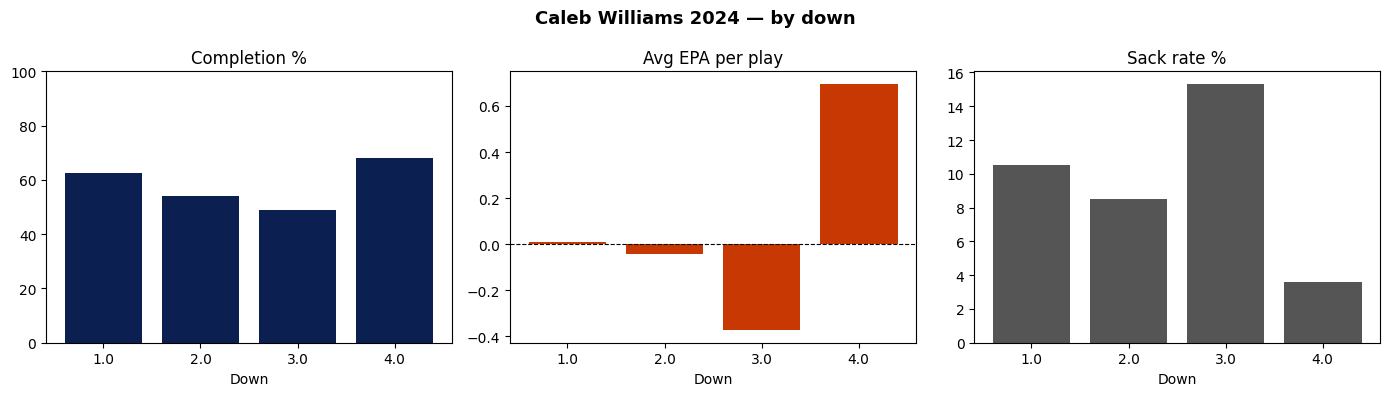

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Caleb Williams 2024 — by down", fontsize=13, fontweight='bold')

downs = caleb_by_down['down'].astype(str)

axes[0].bar(downs, caleb_by_down['comp_pct'], color='#0B1F51')
axes[0].set_title('Completion %')
axes[0].set_xlabel('Down')
axes[0].set_ylim(0, 100)

axes[1].bar(downs, caleb_by_down['avg_epa'], color='#C83803')
axes[1].set_title('Avg EPA per play')
axes[1].set_xlabel('Down')
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')

axes[2].bar(downs, caleb_by_down['sack_rate'], color='#555555')
axes[2].set_title('Sack rate %')
axes[2].set_xlabel('Down')

plt.tight_layout()
plt.show()

## Drilling Into 3rd Down
Breaking 3rd down attempts into distance buckets to pinpoint where 
the struggles were most concentrated.

In [7]:
caleb_3rd = caleb[caleb['down'] == 3].copy()

caleb_3rd['distance_bucket'] = pd.cut(
    caleb_3rd['ydstogo'],
    bins=[0, 3, 6, 10, 100],
    labels=['Short (1-3)', 'Medium (4-6)', 'Long (7-10)', 'Very long (11+)']
)

third_by_dist = caleb_3rd.groupby('distance_bucket', observed=True).agg(
    attempts      = ('complete_pass', 'count'),
    comp_pct      = ('complete_pass', 'mean'),
    avg_epa       = ('epa', 'mean'),
    sack_rate     = ('sack', 'mean'),
    avg_air_yards = ('air_yards', 'mean')
).reset_index()

third_by_dist['comp_pct']      = (third_by_dist['comp_pct'] * 100).round(1)
third_by_dist['avg_epa']       = third_by_dist['avg_epa'].round(3)
third_by_dist['sack_rate']     = (third_by_dist['sack_rate'] * 100).round(1)
third_by_dist['avg_air_yards'] = third_by_dist['avg_air_yards'].round(1)

print(third_by_dist)

   distance_bucket  attempts  comp_pct  avg_epa  sack_rate  avg_air_yards
0      Short (1-3)        28      60.7   -0.053       10.7           12.2
1     Medium (4-6)        47      46.8   -0.274        4.3            9.6
2      Long (7-10)        55      38.2   -0.673       30.9            9.6
3  Very long (11+)        46      56.5   -0.317       10.9            9.0


## Investigating the Cause
With 3rd and long identified as the problem, we look at sacked vs 
non-sacked plays to understand what was driving the high sack rate.
Air yards on non-sacked plays were 9.6 — a reasonable intermediate depth — 
suggesting play calling was not the primary issue.

In [8]:
# Compare air yards and time-pressure indicators on 3rd and long
caleb_3rd_long = caleb_3rd[caleb_3rd['distance_bucket'] == 'Long (7-10)'].copy()

# Look at sacked vs not-sacked plays side by side
sack_compare = caleb_3rd_long.groupby('sack').agg(
    plays         = ('epa', 'count'),
    avg_air_yards = ('air_yards', 'mean'),
    avg_epa       = ('epa', 'mean'),
    qb_hit_rate   = ('qb_hit', 'mean')
).reset_index()

sack_compare['sack'] = sack_compare['sack'].map({0: 'No sack', 1: 'Sacked'})
sack_compare['avg_air_yards'] = sack_compare['avg_air_yards'].round(1)
sack_compare['avg_epa']       = sack_compare['avg_epa'].round(3)
sack_compare['qb_hit_rate']   = (sack_compare['qb_hit_rate'] * 100).round(1)

print(sack_compare)

      sack  plays  avg_air_yards  avg_epa  qb_hit_rate
0  No sack     38            9.6    0.035         13.2
1   Sacked     17            NaN   -2.256        100.0


## Week-by-Week Variance
Checking whether the sack rate was consistent all season or concentrated 
in specific weeks — which would point toward matchup or injury factors.

In [9]:
# Sack rate by week on 3rd and long
sack_by_week = caleb_3rd_long.groupby('week').agg(
    attempts  = ('sack', 'count'),
    sacks     = ('sack', 'sum'),
).reset_index()

sack_by_week['sack_rate'] = (sack_by_week['sacks'] / sack_by_week['attempts'] * 100).round(1)
print(sack_by_week)

    week  attempts  sacks  sack_rate
0      2         3    3.0      100.0
1      3         6    1.0       16.7
2      4         1    1.0      100.0
3      5         1    1.0      100.0
4      6         3    0.0        0.0
5      8         4    0.0        0.0
6      9         6    1.0       16.7
7     10         6    4.0       66.7
8     11         4    0.0        0.0
9     12         3    0.0        0.0
10    13         1    0.0        0.0
11    14         4    3.0       75.0
12    15         4    1.0       25.0
13    16         2    0.0        0.0
14    17         5    2.0       40.0
15    18         2    0.0        0.0


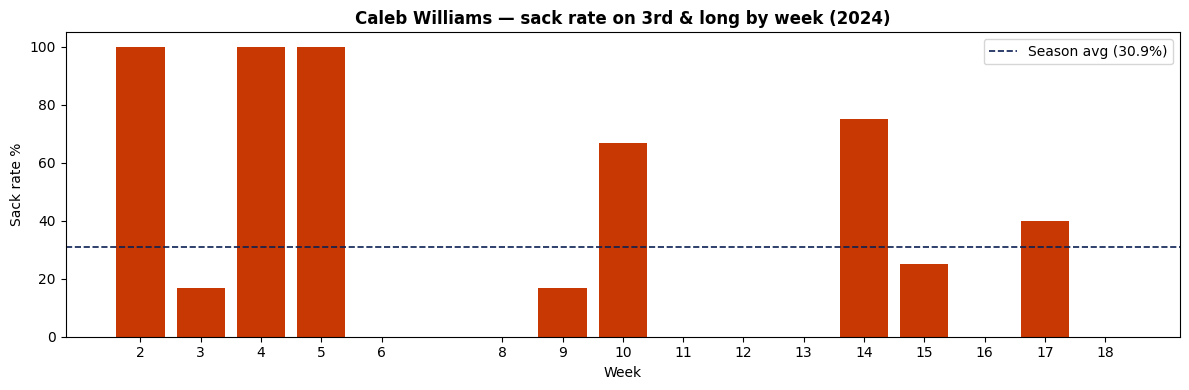

In [10]:
# Visualize it
fig, ax = plt.subplots(figsize=(12, 4))

ax.bar(sack_by_week['week'], sack_by_week['sack_rate'], color='#C83803')
ax.axhline(30.9, color='#0B1F51', linewidth=1.2, linestyle='--', label='Season avg (30.9%)')
ax.set_title("Caleb Williams — sack rate on 3rd & long by week (2024)", fontweight='bold')
ax.set_xlabel('Week')
ax.set_ylabel('Sack rate %')
ax.set_xticks(sack_by_week['week'])
ax.legend()

plt.tight_layout()
plt.show()

## Opponent Analysis
With high week-to-week variance established, we investigate whether 
the Bears faced particularly strong pass-rushing defenses on their 
worst sack rate weeks.

In [11]:
# Add opponent and sack rate together
sack_by_opponent = caleb_3rd_long.groupby('defteam').agg(
    attempts  = ('sack', 'count'),
    sacks     = ('sack', 'sum'),
    avg_epa   = ('epa', 'mean')
).reset_index()

sack_by_opponent['sack_rate'] = (sack_by_opponent['sacks'] / sack_by_opponent['attempts'] * 100).round(1)
sack_by_opponent['avg_epa']   = sack_by_opponent['avg_epa'].round(3)

# Only show opponents with at least 3 attempts so small samples don't dominate
sack_by_opponent = sack_by_opponent[sack_by_opponent['attempts'] >= 3]
sack_by_opponent = sack_by_opponent.sort_values('sack_rate', ascending=False)

print(sack_by_opponent)

   defteam  attempts  sacks  avg_epa  sack_rate
4      HOU         3    3.0   -1.969      100.0
11      SF         4    3.0   -1.500       75.0
9       NE         6    4.0   -1.816       66.7
10     SEA         5    2.0   -0.047       40.0
0      ARI         6    1.0   -0.344       16.7
5      IND         6    1.0   -0.106       16.7
8      MIN         7    1.0   -1.597       14.3
2      DET         3    0.0    1.079        0.0
3       GB         6    0.0   -0.164        0.0
6      JAX         3    0.0    1.416        0.0
12     WAS         4    0.0   -0.668        0.0


## Context — League-Wide Pass Rush Rates
Comparing each opponent's sack rate against the Bears to their 
league-wide sack rate. If opponent quality drove the variance, 
high Bears sack rate opponents should also rank highly league-wide.

In [12]:
# How did these defenses perform against ALL teams, not just the Bears
# This gives context for whether they were generally good pass rush teams

all_qb_hits = pbp_2024[
    (pbp_2024['play_type'] == 'pass')
].groupby('defteam').agg(
    total_attempts = ('sack', 'count'),
    total_sacks    = ('sack', 'sum'),
    total_qb_hits  = ('qb_hit', 'sum')
).reset_index()

all_qb_hits['league_sack_rate'] = (all_qb_hits['total_sacks'] / all_qb_hits['total_attempts'] * 100).round(1)
all_qb_hits['league_hit_rate']  = (all_qb_hits['total_qb_hits'] / all_qb_hits['total_attempts'] * 100).round(1)

# Merge with your Bears-specific data
comparison = sack_by_opponent.merge(
    all_qb_hits[['defteam', 'league_sack_rate', 'league_hit_rate']],
    on='defteam'
)

comparison = comparison.sort_values('sack_rate', ascending=False)
print(comparison[['defteam', 'attempts', 'sack_rate', 'league_sack_rate', 'league_hit_rate']].to_string(index=False))

defteam  attempts  sack_rate  league_sack_rate  league_hit_rate
    HOU         3      100.0               8.4             16.7
     SF         4       75.0               6.7             13.9
     NE         6       66.7               5.0             11.0
    SEA         5       40.0               7.3             17.7
    ARI         6       16.7               7.1             12.6
    IND         6       16.7               6.2             13.6
    MIN         7       14.3               7.1             16.3
    DET         3        0.0               5.4             15.9
     GB         6        0.0               7.4             14.4
    JAX         3        0.0               5.5             10.7
    WAS         4        0.0               7.5             14.8


## Game Script as an Explanation
Testing whether the Bears were trailing significantly on sacked plays — 
which would tip off defenses and make protection harder.
The 3-point gap between sacked (-7.2) and non-sacked (-4.2) situations 
is meaningful but not large enough to explain a 30.9% sack rate alone.

In [13]:
# Check score differential on 3rd and long sacked vs non-sacked plays
caleb_3rd_long['score_diff'] = caleb_3rd_long['posteam_score'] - caleb_3rd_long['defteam_score']

score_compare = caleb_3rd_long.groupby('sack').agg(
    plays     = ('score_diff', 'count'),
    avg_score_diff = ('score_diff', 'mean')
).reset_index()

score_compare['sack'] = score_compare['sack'].map({0: 'No sack', 1: 'Sacked'})
score_compare['avg_score_diff'] = score_compare['avg_score_diff'].round(1)

print(score_compare)

      sack  plays  avg_score_diff
0  No sack     38            -4.2
1   Sacked     17            -7.2


## Conclusion

Caleb Williams' 3rd and long performance in 2024 represented a significant 
vulnerability, with a 30.9% sack rate — nearly 4x the NFL average of ~7.5%.

**Key findings:**
- The problem was concentrated specifically in 3rd and long (7-10 yards), 
not across all distances
- Week-to-week variance was high, ruling out a consistent systemic failure
- Opponent pass rush quality did not explain the variance — defenses with 
similar league-wide sack rates produced wildly different results against Chicago
- Game script was a minor contributing factor but not the primary driver

**Conclusion:** The vulnerability appears schematic or situational rather 
than a straightforward personnel failure. See the 2025 notebook for the 
year-over-year comparison.

### Caveats
- Opponent-level findings rest on samples of 3–4 plays per team and should 
be treated as directional
- EPA models carry their own assumptions and should be treated as directional 
rather than precise
- This analysis covers pass plays only